###   Лабараторная работа 6

####  Сколько я смогу получить


In [3]:
import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
import random
import scipy.stats as stats
import pylab 


%matplotlib inline

In [38]:
n_exp = 100000
count_stat = 9
crit_choice = [5.44, 6.22, 6.99, 7.77]
count_rolls = [8, 8, 8, 8, 9]
count_8_crit_rolls = [4, 5, 5, 6]
count_9_crit_rolls = [4, 5, 5, 5, 6, 6, 6, 7]

crit_func = []

### Шансы критмассы

In [39]:
for i in range(n_exp):
    art_rolls = random.choice(count_rolls)
    art_crit_rolls = 0
    if art_rolls == 8:
        art_crit_rolls = random.choice(count_8_crit_rolls)
    else:
        art_crit_rolls = random.choice(count_9_crit_rolls)
        
    crit_value = sum(random.choices(crit_choice, k = art_crit_rolls))
    crit_func.append(crit_value)

data_frame = pd.DataFrame(crit_func)
data_frame_desc = data_frame.describe()
sorted = data_frame.sort_values(by=[0])
data_frame.quantile([0.10, 0.20, .40, .50, .55, .60, .65, .70, .75, .80, .85, .90, .95, .99, .999, 1])

,0
0.100,26.42
0.200,28.75
0.400,32.63
0.500,33.41
0.550,34.19
0.600,34.96
0.650,34.98
0.700,36.52
0.750,38.07
0.800,38.85


In [48]:
x=[]
y=[]
i = 21
prob = 0
for i in range(21, 56):
    prob = len(sorted[sorted[0] >= i])/n_exp
    x.append(i)
    y.append(prob)
    i+=1
    

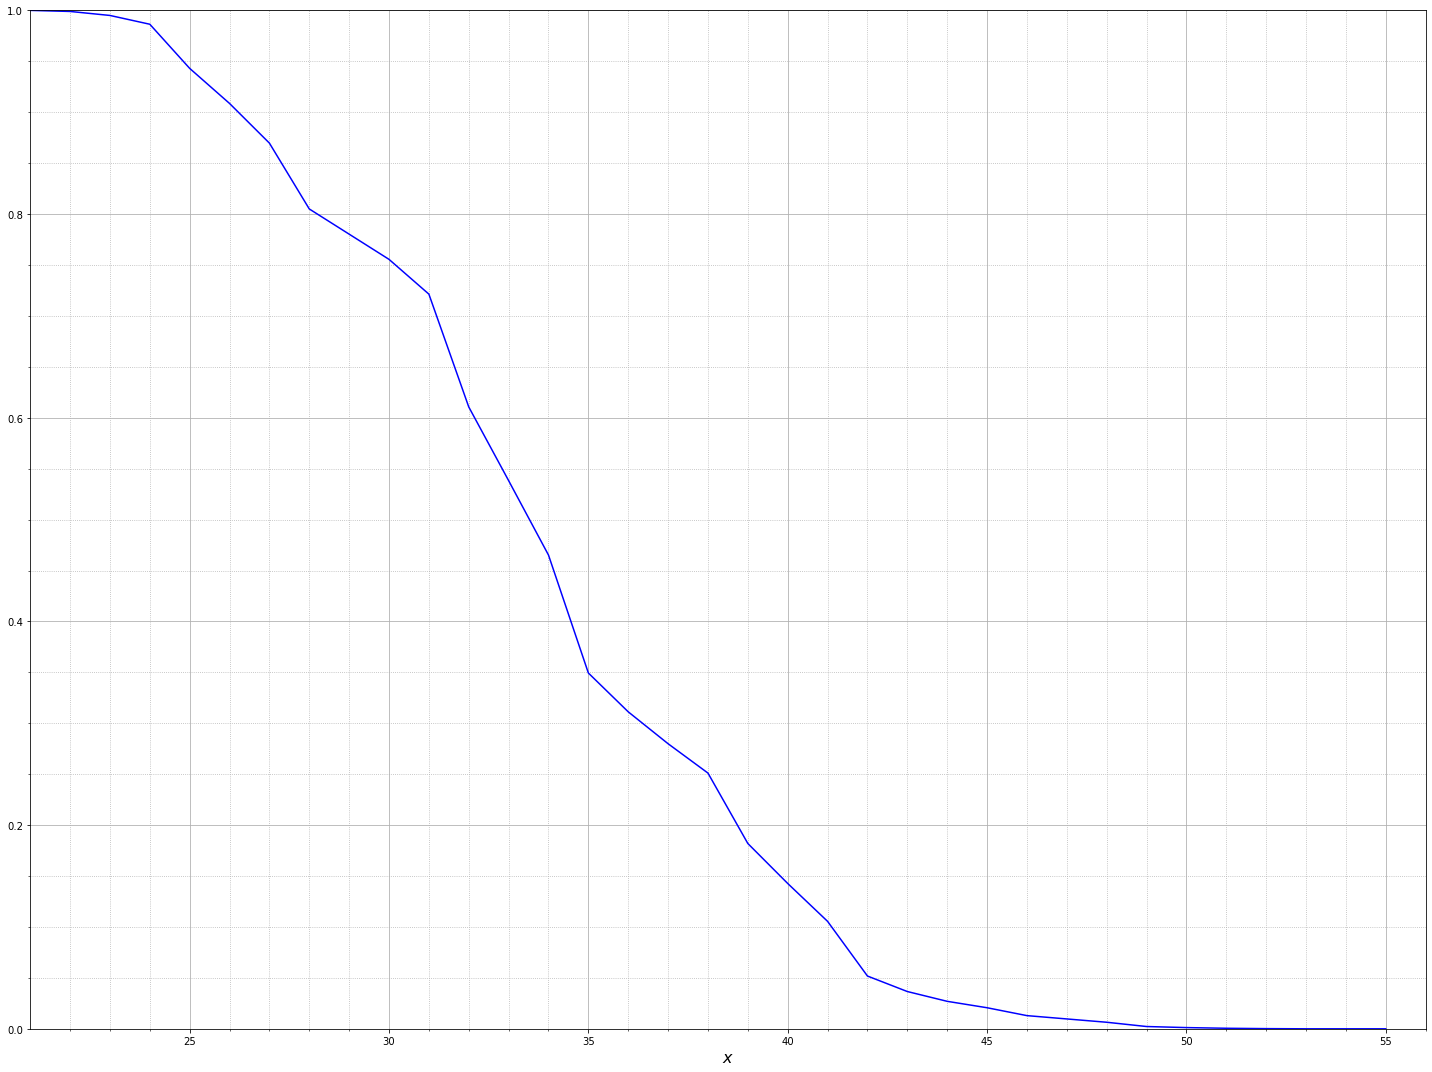

In [49]:
plt.figure(figsize=(20, 15))

# включаем дополнительные отметки на осях
plt.minorticks_on()
plt.xlabel(r'$x$', fontsize=16)

plt.xlim([21., 56.])
plt.ylim([0., 1.])
# включаем основную сетку
plt.grid(which='major')
# включаем дополнительную сетку
plt.grid(which='minor', linestyle=':')
plt.tight_layout()

plt.plot(x, y, color ='blue')

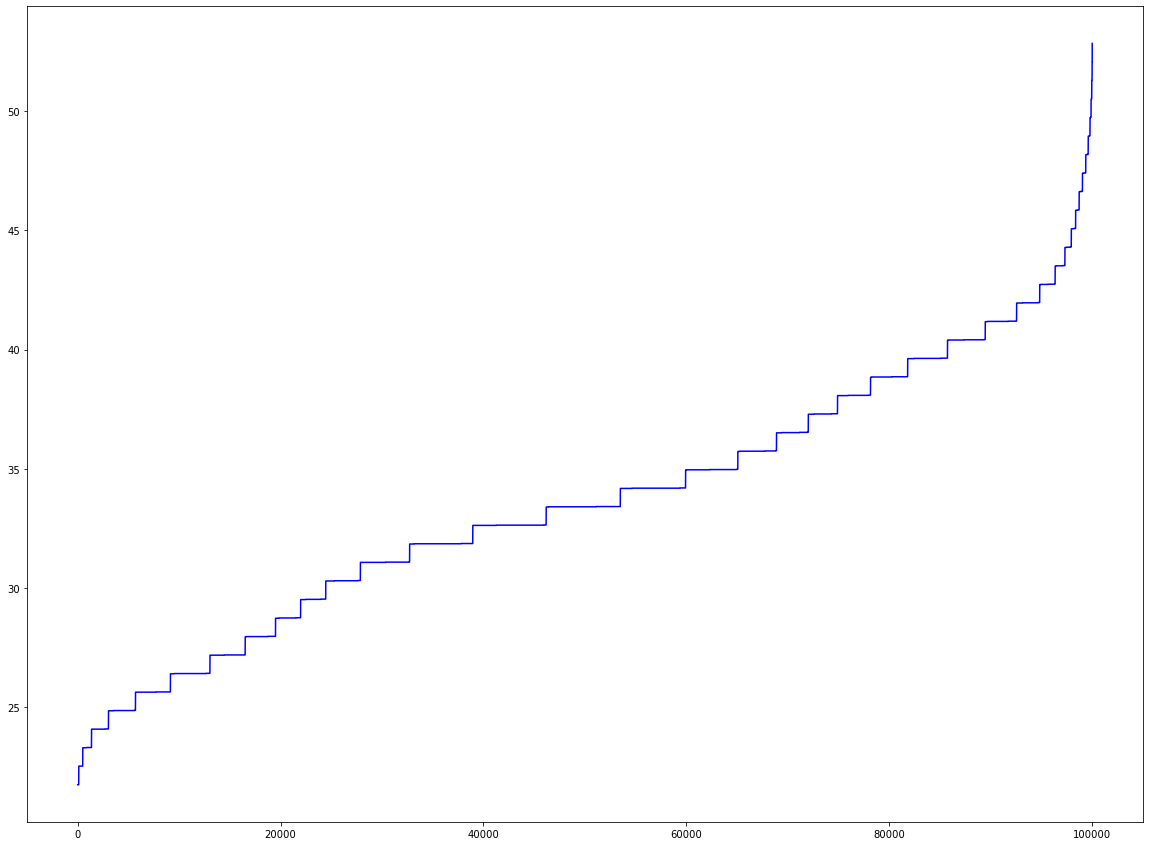

In [41]:
plt.figure(figsize=(20, 15))
plt.plot(range(0, n_exp), sorted[0], color ='blue')

In [42]:
sorted[0]

49999    21.76
30015    21.76
59417    21.76
60146    21.76
60346    21.76
         ...  
67697    52.06
36527    52.83
69284    52.83
6221     52.83
27299    52.83
Name: 0, Length: 100000, dtype: float64

### Ивентовый 5* герой

In [3]:
for i in range(n_exp):
    art_stats = random.sample(range(1,count_stat+1), 4)
    crit_factor = 0
    for stat in art_stats:
        if stat < 3:
            crit_factor += random.choice(crit_choice)
            
    
    count_rolls = 4 + random.choice([0, 1])
    for i in range(count_rolls):
        roll = random.choice(art_stats)
        if roll < 3:
            crit_factor += random.choice(crit_choice)
    if crit_factor > 1:
        crit_func.append(crit_factor)

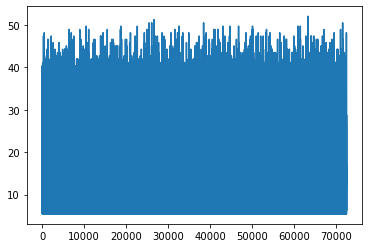

In [4]:
plt.plot(crit_func)

In [5]:
min(crit_func)

5.44

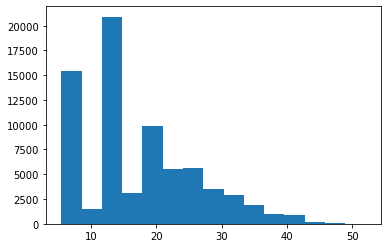

In [6]:
plt.hist(crit_func, 15)
plt.show()

In [7]:

hist = np.histogram(crit_func, bins=100)
hist_dist = stats.rv_histogram(hist)

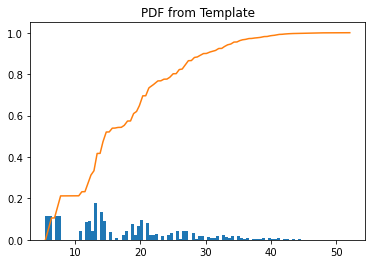

In [8]:

X = np.linspace(max(crit_func), min(crit_func), len(crit_func))
plt.title("PDF from Template")
plt.hist(crit_func, density=True, bins=100)
#plt.plot(X, hist_dist.pdf(X), label='PDF')
plt.plot(X, hist_dist.cdf(X), label='CDF')
plt.show()

In [19]:
#crit_func = np.array(crit_func)*-1
#H = hist_dist.cdf(X)
#1-H

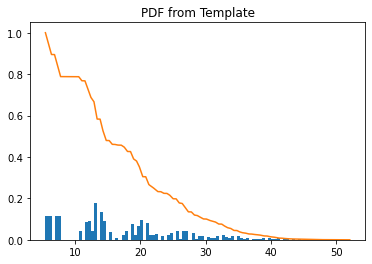

In [9]:
plt.title("PDF from Template")
plt.hist(crit_func, density=True, bins=100)
#plt.plot(X, hist_dist.pdf(X), label='PDF')
plt.plot(X, 1-hist_dist.cdf(X), label='CDF')
plt.show()

In [13]:
crit_func = np.sort(crit_func)[::-1]
crit_func

array([52.06, 51.27, 50.51, ...,  5.44,  5.44,  5.44])

In [12]:
print(1-hist_dist.cdf(X)[1000], crit_func[1000])
print(1-hist_dist.cdf(X)[1], crit_func[1])

1.9033632873588502e-05 -5.44
1.9033633336107414e-08 -5.44


In [20]:
def nearest_value(items, value):
    '''Поиск ближайшего значения до value в списке items'''
    found = items[0] # найденное значение (первоначально первое)
    ind = 0
    for i in range(len(items)):
        if abs(items[i] - value) < abs(found - value):
            found = items[i]
            ind = i
    return ind

In [22]:
ind50 = nearest_value(crit_func, 50)
ind45 = nearest_value(crit_func, 45)
ind40 = nearest_value(crit_func, 40)

In [24]:
ind40

1037

In [51]:
H[ind45]**50

2.1610799565934522e-273

In [34]:
H[ind50] * H[ind40]

2.2541010689990806e-12

In [45]:
x = H[ind45]**2 / (H[ind50] * H[ind40])

In [46]:
np.log10(x)/(1+np.log10(x))

0.4254238836800278